In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
orders = pd.read_csv('../Data/raw_data/olist_orders_dataset.csv',
                     parse_dates=['order_purchase_timestamp'])
customers = pd.read_csv('../Data/raw_data/olist_customers_dataset.csv')
payments = pd.read_csv('../Data/raw_data/olist_order_payments_dataset.csv')

print('Data loaded!')

Data loaded!


In [3]:
delivered = orders[orders['order_status'] == 'delivered']

df = delivered.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')

order_payment = payments.groupby('order_id')['payment_value'].sum().reset_index()
df = df.merge(order_payment, on='order_id')

print('Rows in analysis table  :', len(df))
print('Unique customers        :', df['customer_unique_id'].nunique())
print('Total payment value     :', round(df['payment_value'].sum(), 2))
df.head()

Rows in analysis table  : 96477
Unique customers        : 93357
Total payment value     : 15422461.77


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [4]:
ref_date = df['order_purchase_timestamp'].max()

rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (ref_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('payment_value', 'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print('Reference date:', ref_date)
rfm.describe()

Reference date: 2018-08-29 15:00:37


,recency,frequency,monetary
count,93357.000000,93357.000000,93357.000000
mean,236.936673,1.033420,165.198772
std,152.584315,0.209099,226.314579
min,0.000000,1.000000,9.590000
25%,113.000000,1.000000,63.060000
50%,218.000000,1.000000,107.780000
75%,345.000000,1.000000,182.560000
max,694.000000,15.000000,13664.080000


In [5]:
rfm['r_score'] = pd.qcut(rfm['recency'].rank(method='first'),
                         q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['f_score'] = rfm['frequency'].apply(lambda x: 4 if x > 1 else 1)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                         q=4, labels=[1, 2, 3, 4]).astype(int)

rfm['rfm_code'] = (rfm['r_score'].astype(str) +
                   rfm['f_score'].astype(str) +
                   rfm['m_score'].astype(str))

rfm[['customer_unique_id', 'recency', 'frequency', 'monetary',
     'r_score', 'f_score', 'm_score', 'rfm_code']].head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_code
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,3,1,1,311
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2,1,4,214


In [6]:
def assign_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 3 and f == 4 and m >= 3:
        return 'Champions'
    elif r >= 3 and f == 4:
        return 'Loyal Customers'
    elif r == 2 and f == 4:
        return 'Needs Attention (Repeat)'
    elif r == 1 and f == 4:
        return 'Cant Lose Them (At Risk)'
    elif r >= 3 and f == 1 and m >= 3:
        return 'Promising High-Spenders'
    elif r == 1 and m == 1:
        return 'Lost / Churned'
    else:
        return 'Standard One-Time Buyers'

rfm['customer_segment'] = rfm.apply(assign_segment, axis=1)

rfm['customer_segment'].value_counts()

customer_segment
Standard One-Time Buyers    62114
Promising High-Spenders     22475
Lost / Churned               5967
Champions                    1373
Needs Attention (Repeat)      676
Cant Lose Them (At Risk)      582
Loyal Customers               170
Name: count, dtype: int64

In [7]:
seg_summary = rfm.groupby('customer_segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_spend=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).sort_values('total_revenue', ascending=False).reset_index()

seg_summary['customer_pct'] = (seg_summary['customer_count'] /
                               seg_summary['customer_count'].sum() * 100).round(2)
seg_summary['revenue_pct'] = (seg_summary['total_revenue'] /
                              seg_summary['total_revenue'].sum() * 100).round(2)
seg_summary['avg_spend'] = seg_summary['avg_spend'].round(2)
seg_summary['total_revenue'] = seg_summary['total_revenue'].round(2)

seg_summary

,customer_segment,customer_count,avg_spend,total_revenue,customer_pct,revenue_pct
0,Standard One-Time Buyers,62114,135.65,8425603.48,66.53,54.63
1,Promising High-Spenders,22475,261.26,5871818.72,24.07,38.07
2,Champions,1373,343.67,471859.89,1.47,3.06
3,Lost / Churned,5967,43.69,260682.36,6.39,1.69
4,Needs Attention (Repeat),676,309.10,208954.20,0.72,1.35
5,Cant Lose Them (At Risk),582,291.37,169578.30,0.62,1.10
6,Loyal Customers,170,82.15,13964.82,0.18,0.09


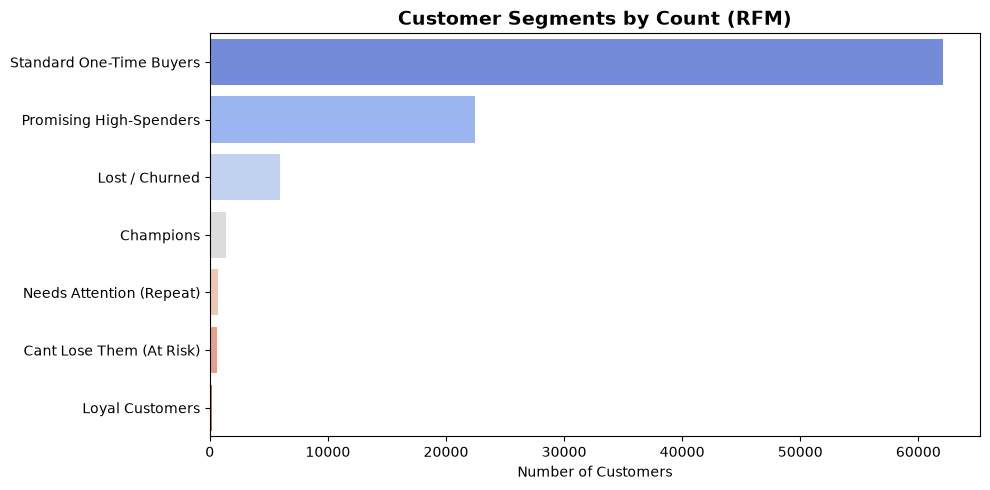

In [8]:
seg_order = seg_summary.sort_values('customer_count', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='customer_count', y='customer_segment', data=seg_order, palette='coolwarm')
plt.title('Customer Segments by Count (RFM)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()

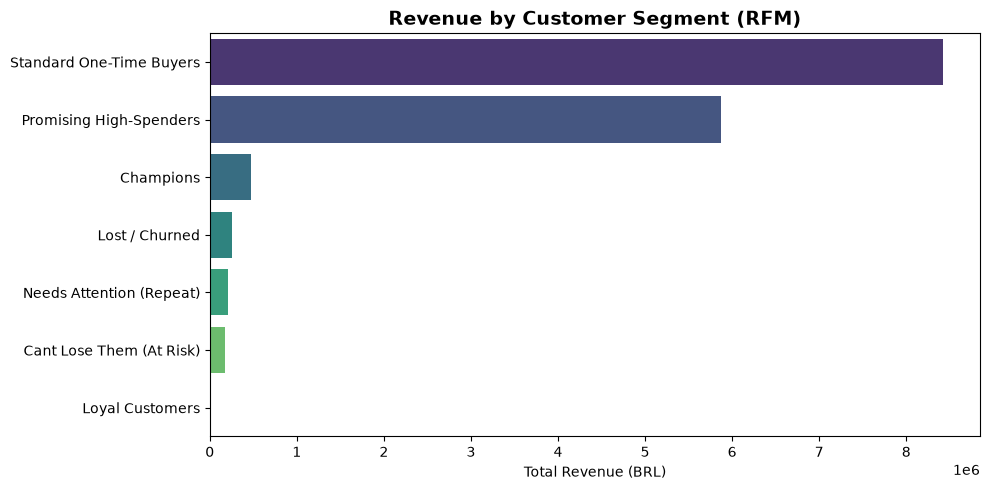

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(x='total_revenue', y='customer_segment', data=seg_summary, palette='viridis')
plt.title('Revenue by Customer Segment (RFM)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('rfm_revenue.png', dpi=150)
plt.show()

In [10]:
rfm.to_csv('../Data/analysed_data/rfm_output.csv', index=False)
seg_summary.to_csv('../Data/analysed_data/rfm_segment_summary.csv', index=False)

print('rfm_output.csv saved!')
print('rfm_segment_summary.csv saved!')

rfm_output.csv saved!
rfm_segment_summary.csv saved!
